# NumPy Homework: Machine Learning Foundations

Work through these exercises after the NumPy teaching notebook.

Before running code, try to predict the shape of the result.

In [158]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)

## Homework 1 — Array inspection


Tasks:

1. Print each array.
2. Print shape, ndim, dtype, and size.
3. Write one comment explaining what each shape means.

In [159]:
a = np.array([3, 5, 7, 9])
B = np.array([[1, 2, 3], [4, 5, 6]])
C = np.array([[170, 65], [180, 80], [160, 55], [175, 72]])

# Write your code here.
for i in [a, B, C]:
    print(f"shape: {i.shape}")
    print(f"dim: {i.ndim}")
    print(f"dtype: {i.dtype}")
    print(f"sizze: {i.size}")

shape: (4,)
dim: 1
dtype: int32
sizze: 4
shape: (2, 3)
dim: 2
dtype: int32
sizze: 6
shape: (4, 2)
dim: 2
dtype: int32
sizze: 8


## Homework 2 — Elementwise operations


A model outputs raw scores.

Tasks:

1. Add 1 to every score.
2. Multiply every score by 2.
3. Square every score.
4. Compute sigmoid probabilities.
5. Convert probabilities to predictions with threshold 0.5.

In [160]:
scores = np.array([-2.0, -0.5, 0.0, 1.0, 2.5])

# Write your code here.
scores += 1
print(scores)
scores /= 2
print(scores)
scores **= 2
print(scores)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

scores = np.array([-2.0, -0.5, 0.0, 1.0, 2.5])

logit = sigmoid(scores)
print(logit)
pred = np.where(logit > 0.5, 1, 0)
print(pred)

[-1.   0.5  1.   2.   3.5]
[-0.5   0.25  0.5   1.    1.75]
[0.25  0.062 0.25  1.    3.062]
[0.119 0.378 0.5   0.731 0.924]
[0 0 0 1 1]


## Homework 3 — Axis statistics


Rows are students. Columns are exams: math, physics, programming.

Tasks:

1. Average score per exam.
2. Average score per student.
3. Best score in each exam.
4. Lowest score for each student.
5. Index of the student with the highest average.

In [161]:
scores = np.array([
    [18, 17, 19],
    [12, 15, 14],
    [20, 19, 18],
    [10, 13, 12],
    [16, 18, 17]
])

# Write your code here.
print(np.mean(scores, axis=0))
avg = np.mean(scores, axis=1)
print(avg)
print(np.max(scores, axis=0))
print(np.min(scores, axis=1))
print(np.argmax(avg, axis=0))


[15.2 16.4 16. ]
[18.    13.667 19.    11.667 17.   ]
[20 19 19]
[17 12 18 10 16]
2


## Homework 4 — Indexing and slicing


Columns are height, weight, age.

Tasks:

1. Extract height column.
2. Extract weight column.
3. Extract first two samples.
4. Extract height and weight only.
5. Extract age of the third person.
6. Compute average height.

In [162]:
X = np.array([
    [170, 65, 16],
    [180, 80, 17],
    [160, 55, 15],
    [175, 72, 16],
    [168, 60, 15]
])

# Write your code here.
height = X[:,0]
print(height)
print(X[:,1])
print(X[0:2])
print(X[:,0:2])
print(X[2,2])

print(np.mean(height))

[170 180 160 175 168]
[65 80 55 72 60]
[[170  65  16]
 [180  80  17]]
[[170  65]
 [180  80]
 [160  55]
 [175  72]
 [168  60]]
15
170.6


## Homework 5 — Boolean masks


Tasks:

1. Convert probabilities to predictions.
2. Compute correct/incorrect mask.
3. Compute accuracy.
4. Select probabilities where the model was wrong.
5. Find wrong indices.
6. Count high-confidence probabilities: at least 0.8.
7. Count uncertain probabilities: between 0.45 and 0.60 inclusive.

In [163]:
probs = np.array([0.91, 0.22, 0.73, 0.48, 0.55, 0.99, 0.31, 0.62])
labels = np.array([1, 0, 1, 1, 0, 1, 0, 1])

# Write your code here.
pred = np.where(probs > 0.5, 1, 0)
tp_tn = (pred == labels).astype(int)
print(tp_tn.sum() / len(labels))

fp_fn = (pred != labels).astype(int)
print(fp_fn)

high = np.where(probs > 0.8, 1, 0)
print(high)


uncertain = np.where((probs < 0.6) & (probs > 0.45), 1, 0)
print(uncertain)

0.75
[0 0 0 1 1 0 0 0]
[1 0 0 0 0 1 0 0]
[0 0 0 1 1 0 0 0]


## Homework 6 — Standardization


Columns are height and weight.

Tasks:

1. Compute feature means.
2. Compute feature standard deviations.
3. Standardize the dataset.
4. Check the mean and std of the standardized data along axis 0.

In [164]:
X = np.array([
    [170, 65],
    [180, 80],
    [160, 55],
    [175, 72],
    [168, 60],
    [190, 90]
])

# Write your code here.
print(np.mean(X, axis=0))
print(np.std(X, axis=0))

X_centered = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
print(X_centered)
print(np.mean(X_centered, axis=0))
print(np.std(X_centered))

[173.833  70.333]
[ 9.494 11.926]
[[-0.404 -0.447]
 [ 0.65   0.811]
 [-1.457 -1.286]
 [ 0.123  0.14 ]
 [-0.614 -0.866]
 [ 1.703  1.649]]
[-0.  0.]
1.0


## Homework 7 — Min-max scaling


Tasks:

1. Compute column-wise minimum.
2. Compute column-wise maximum.
3. Apply min-max scaling.
4. Check that each scaled column has min 0 and max 1.

In [165]:
X = np.array([
    [10, 100],
    [20, 150],
    [30, 200],
    [40, 250],
    [50, 300]
])

# Write your code here.
max = np.max(X, axis=0)
min = np.min(X, axis=0)
print(max)
print(min)
min_max_X = (X - min) / (max-min)
print(min_max_X)
print(np.min(min_max_X, axis=0))
print(np.max(min_max_X, axis=0))

[ 50 300]
[ 10 100]
[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [0.75 0.75]
 [1.   1.  ]]
[0. 0.]
[1. 1.]


## Homework 8 — Linear model forward pass


For a linear model:

```python
preds = X @ w + b
```

Tasks:

1. Print shapes.
2. Compute predictions.
3. Manually verify the first prediction in a comment.
4. Compute errors.
5. Compute mean squared error.

In [166]:
X = np.array([[1, 2], [2, 1], [3, 4], [4, 3], [5, 5]])
w = np.array([3, -2])
b = 5
y = np.array([4, 9, 6, 11, 10])

# Write your code here.
print(X.shape, w.shape)
pred = X @ w + b
print(pred)
error = pred - y
mse = np.mean(error**2)
print(mse)

(5, 2) (2,)
[ 4  9  6 11 10]
0.0


## Homework 9 — Confusion counts


Tasks:

1. Convert probabilities to predictions.
2. Compute TP, TN, FP, FN using boolean masks.
3. Compute accuracy.
4. Store the counts in a dictionary.

In [167]:
probs = np.array([0.9, 0.8, 0.3, 0.4, 0.7, 0.2, 0.6, 0.51, 0.49])
labels = np.array([1, 0, 0, 0, 1, 1, 1, 0, 0])

# Write your code here.

pred = np.where(probs > 0.5, 1, 0)

tp = np.sum((pred == 1) & (labels == 1))
tn = np.sum((pred == 0) & (labels == 0))
fp = np.sum((pred == 1) & (labels == 0))
fn = np.sum((pred == 0) & (labels == 1))

accuracy = (tp + tn) / (tp + tn + fp + fn)
print(accuracy)

dict = {"tp":tp, "tn":tn,
        "fp":fp,"fn":fn,}
print(dict)

0.6666666666666666
{'tp': 3, 'tn': 3, 'fp': 2, 'fn': 1}


## Homework 10 — Mini NumPy AI pipeline


Columns are hours studied and practice tests.

Tasks:

1. Print the shape of X.
2. Standardize X.
3. Compute scores using X_scaled @ w + b.
4. Convert scores to probabilities with sigmoid.
5. Convert probabilities to predictions.
6. Compute accuracy.
7. Print wrong indices.
8. Print the original samples where the model was wrong.

In [168]:
X = np.array([
    [2, 1], [3, 1], [4, 2], [5, 2],
    [6, 3], [7, 3], [8, 4], [9, 4]
])
y = np.array([0, 0, 0, 1, 1, 1, 1, 1])
w = np.array([1.1, 0.9])
b = -0.2

# Write your code here.
print(X.shape)

print(np.mean(X, axis=0))
print(np.std(X, axis=0))

X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

scores = X_scaled @ w + b

prob = sigmoid(scores)
pred = np.where(prob > 0.5, 1, 0)
print(pred)

tp = np.sum((pred == 1) & (y == 1))
tn = np.sum((pred == 0) & (y == 0))
fp = np.sum((pred == 1) & (y == 0))
fn = np.sum((pred == 0) & (y == 1))

accuracy = (tp + tn) / (tp + tn + fp + fn)
print(accuracy)

(8, 2)
[5.5 2.5]
[2.291 1.118]
[0 0 0 0 1 1 1 1]
0.875


## Homework 11 — One gradient descent step


Harder task.

For linear regression:

```python
preds = X @ w + b
errors = preds - y
grad_w = (2 / n) * X.T @ errors
grad_b = 2 * errors.mean()
```

Tasks:

1. Compute predictions, errors, and MSE.
2. Compute grad_w and grad_b.
3. Update w and b.
4. Compute the new MSE after one update.

mse: 70.8 | w: [0.536 0.496] | b: 0.032
mse: 28.658547199999997 | w: [0.847 0.767] | b: 0.051488000000000006
mse: 15.1654005721088 | w: [1.031 0.912] | b: 0.06391001600000001
mse: 10.807405910209228 | w: [1.143 0.985] | b: 0.07234120448000002
mse: 9.362923543217638 | w: [1.214 1.018] | b: 0.07851798869811202
mse: 8.848216008572596 | w: [1.263 1.028] | b: 0.08342086073023695
mse: 8.630770113784818 | w: [1.298 1.025] | b: 0.08760346737561035
mse: 8.508900829291951 | w: [1.326 1.015] | b: 0.09137843231571065
mse: 8.418289732105418 | w: [1.35  1.001] | b: 0.09492228274332304
mse: 8.338416936133132 | w: [1.371 0.985] | b: 0.0983346973959895
[ 3.447  3.795  8.148  8.497 11.848]


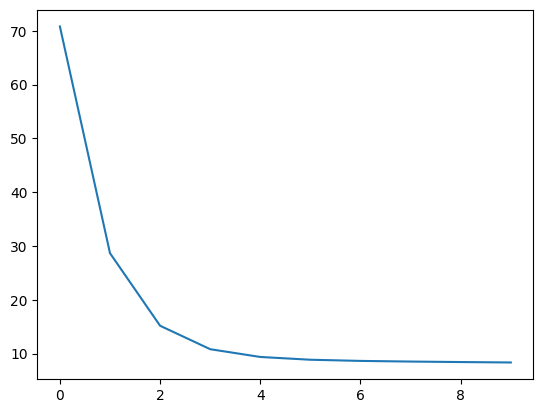

In [199]:
X = np.array([[1, 2], [2, 1], [3, 4], [4, 3], [5, 5]], dtype=float)
y = np.array([4, 9, 6, 11, 10], dtype=float)
w = np.array([0.0, 0.0])
b = 0.0
lr = 0.01

# Write your code here.
import matplotlib.pyplot as plt

n = len(y)
loss = []
for i in range(10):
    
    pred = X @ w + b
    error = pred - y
    mse = np.mean(error**2)
    loss.append(mse)

    grad_w = (2/n) * X.T @ error
    grad_b = (2/n) * error.mean()

    w -= lr * grad_w
    b -= lr * grad_b
    
    print(f"mse: {mse} | w: {w} | b: {b}")

print(pred)
plt.plot(loss)


## Homework 12 — Nearest centroid with NumPy


You already studied KNN and KMeans. Now solve a centroid assignment task with NumPy.

Tasks:

1. Compute distance from each sample to each centroid.
2. Assign each sample to the nearest centroid.
3. Count how many samples are assigned to each centroid.
4. Try both a loop version and a NumPy broadcasting version.

In [201]:
X = np.array([
    [1.0, 1.0], [1.5, 1.2], [5.0, 5.0],
    [5.5, 4.8], [9.0, 1.0], [8.5, 1.3]
])
centroids = np.array([[1.0, 1.0], [5.0, 5.0], [9.0, 1.0]])

# Write your code here.

distances = np.linalg.norm(
    X[:, None] - centroids,
    axis=2
)

print(distances)

labels = np.argmin(distances, axis=1)

print(labels)

counts = np.bincount(labels, minlength=len(centroids))

print(counts)

[[0.    5.657 8.   ]
 [0.539 5.166 7.503]
 [5.657 0.    5.657]
 [5.89  0.539 5.166]
 [8.    5.657 0.   ]
 [7.506 5.093 0.583]]
[0 0 1 1 2 2]
[2 2 2]
